In [ ]:
import torch
import torch.nn as nn
import tiktoken

In [ ]:
from gpt import GPTConfig, GPTModel

torch.manual_seed(42)
gpt_cfg = GPTConfig(context_length=256)
model = GPTModel(gpt_cfg)
model.eval()

In [ ]:
from gpt import generate_text
from utils import text_to_tokens, tokens_to_text

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
input_tokens = text_to_tokens(start_context, tokenizer)
generated_tokens = generate_text(
    model, input_tokens, max_length=10, context_length=gpt_cfg.context_length
)
generated_text = tokens_to_text(generated_tokens, tokenizer)
print(generated_text)

Every effort moves youodonuyomiassin Basic batted JavierPandottestriver Pearce


In [9]:
input_tokens_2 = text_to_tokens("I need some coffee", tokenizer)
inputs = torch.stack([input_tokens[0][:-1], input_tokens_2[0][:-1]])
targets = torch.stack([input_tokens[0][1:], input_tokens_2[0][1:]])
print("Inputs:", inputs)
print("Targets:", targets)

Inputs: tensor([[6109, 3626, 6100],
        [  40,  761,  617]])
Targets: tensor([[3626, 6100,  345],
        [ 761,  617, 6891]])


In [16]:
with torch.no_grad():
    logits = model(inputs)
probs = torch.softmax(logits, dim=-1)
token_ids = torch.argmax(probs, dim=-1, keepdim=True)
print("Predicted token IDs of batch 1:", token_ids[0])
predicted_text = tokens_to_text(token_ids[0].flatten(), tokenizer)
print("Predicted text of batch 1:", predicted_text)

Predicted token IDs of batch 1: tensor([[23392],
        [44449],
        [40115]])
Predicted text of batch 1:  optimized relativity HO


## text evaluation

In [22]:
text_idx = 0
target_probs_1 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probs_1)

text_idx = 1
target_probs_2 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probs_2)

log_probs = torch.log(torch.cat((target_probs_1, target_probs_2)))
print("Log probabilities of target tokens:", log_probs)

loss = -log_probs.mean()
print("Loss:", loss)

Text 1: tensor([1.0803e-05, 2.5454e-05, 1.1681e-05])
Text 2: tensor([2.0838e-05, 7.2046e-06, 3.8248e-05])
Log probabilities of target tokens: tensor([-11.4357, -10.5786, -11.3575, -10.7787, -11.8408, -10.1714])
Loss: tensor(11.0271)


In [23]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Logits shape:", logits_flat.shape)
print("Targets shape:", targets_flat.shape)

loss = nn.functional.cross_entropy(logits_flat, targets_flat)
print("Cross-entropy loss:", loss)

Logits shape: torch.Size([6, 50257])
Targets shape: torch.Size([6])
Cross-entropy loss: tensor(11.0271)


## training model

In [ ]:
fp = "./the-verdict.txt"
with open(fp, "r") as f:
    text = f.read()

print("Number of characters:", len(text))
print("Number of tokens:", len(tokenizer.encode(text)))

Number of characters: 20479
Number of tokens: 5145


In [27]:
train_ratio = 0.9
train_size = int(len(text) * train_ratio)
train_data = text[:train_size]
valid_data = text[train_size:]

In [ ]:
from utils import create_dataloader_v1

torch.manual_seed(42)
train_dataloader = create_dataloader_v1(
    train_data,
    context_size=gpt_cfg.context_length,
    stride=gpt_cfg.context_length,
    batch_size=2,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)
valid_dataloader = create_dataloader_v1(
    valid_data,
    context_size=gpt_cfg.context_length,
    stride=gpt_cfg.context_length,
    batch_size=2,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

In [ ]:
from train import calc_loss_dataloader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_dataloader(train_dataloader, model)
    valid_loss = calc_loss_dataloader(valid_dataloader, model)
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {valid_loss:.4f}")

Training Loss: 11.0040
Validation Loss: 11.0441


In [ ]:
from train import train_model

torch.manual_seed(42)
model = GPTModel(gpt_cfg)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)
num_epochs = 10
train_losses, valid_losses, track_tokens_seen = train_model(
    model,
    train_dataloader,
    valid_dataloader,
    optimizer,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    tokenizer=tokenizer,
    start_context=start_context,
)

Epoch 1/10, Step 5, Train Loss: 9.4562, Valid Loss: 9.6335
Every effort moves you, the,, the,, the,,,, the, the,,, the the, the,,, the,, the,,,, the,,, the,,, the,, the,,, the,
Epoch 2/10, Step 10, Train Loss: 8.8250, Valid Loss: 9.0365
Epoch 2/10, Step 15, Train Loss: 8.2756, Valid Loss: 8.5586
Every effort moves you, the, the, the, the, the, the the, the, the, the the, the, the, the.                       
Epoch 3/10, Step 20, Train Loss: 7.7634, Valid Loss: 8.0986
Epoch 3/10, Step 25, Train Loss: 7.2495, Valid Loss: 7.6748
Every effort moves you, the, the, the, the, the, the, the, the, the, the, the, the, the.                       
Epoch 4/10, Step 30, Train Loss: 6.7836, Valid Loss: 7.3403
Epoch 4/10, Step 35, Train Loss: 6.3496, Valid Loss: 7.0584
Every effort moves you, and, and, and, and, and, and I, and, and, and the, and, and, and.                       
Epoch 5/10, Step 40, Train Loss: 5.9303, Valid Loss: 6.8791
Epoch 5/10, Step 45, Train Loss: 5.4653, Valid Loss: 6.7272
Eve

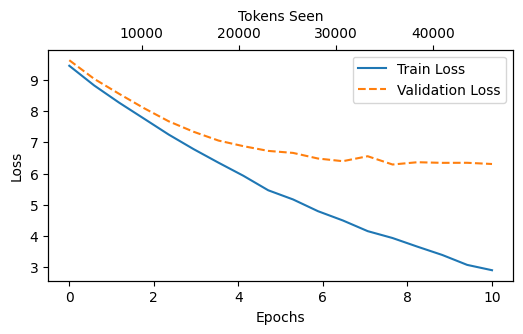

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_loss(train_losses, valid_losses, tokens_seen, epochs_seen):
    _, ax1 = plt.subplots(figsize=(6, 3))
    ax1.plot(epochs_seen, train_losses, label="Train Loss")
    ax1.plot(epochs_seen, valid_losses, label="Validation Loss", linestyle='--')
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens Seen")
    plt.show()

epochs_seen = torch.linspace(0, num_epochs, len(train_losses))
plot_loss(train_losses, valid_losses, track_tokens_seen, epochs_seen)

## Decoding strategies

In [59]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")
input_tokens = text_to_tokens(start_context, tokenizer)
token_ids = generate_text(model, input_tokens, 25, gpt_cfg.context_length)
print(tokens_to_text(token_ids, tokenizer))

Every effort moves you know I was not that I felt as his pictures--I had the one of the: "








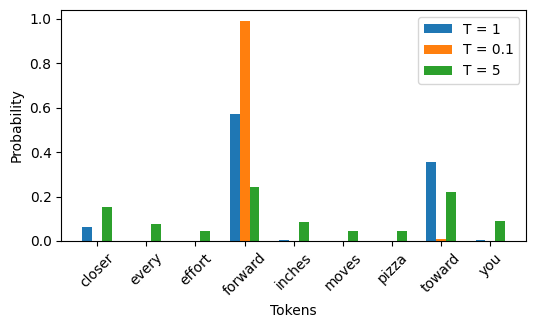

In [ ]:
# temperature scaling

vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.2
_, ax = plt.subplots(figsize=(6, 3))
for i, (T, probas) in enumerate(zip(temperatures, scaled_probas)):
    ax.bar(x + (i - 1) * bar_width, height=probas, width=bar_width, label=f"T = {T}")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=45)
ax.set_xlabel("Tokens")
ax.set_ylabel("Probability")
ax.legend()
plt.show()

In [ ]:
top_k = 3
top_k_logits, top_k_indices = torch.topk(next_token_logits, k=top_k)
print(f"Top-{top_k} token indices: {top_k_indices}")
print(f"Top-{top_k} token logits: {top_k_logits}")

Top-3 token indices: tensor([3, 7, 0])
Top-3 token logits: tensor([6.7500, 6.2800, 4.5100])


In [82]:
torch.topk(next_token_logits, k=top_k).indices


tensor([3, 7, 0])

In [ ]:
top_k_mask = torch.ones_like(next_token_logits, dtype=torch.bool)
top_k_mask[top_k_indices] = False
filtered_logits = next_token_logits.masked_fill(top_k_mask, float("-inf"))
filtered_probs = torch.softmax(filtered_logits, dim=0)
print(f"Filtered probabilities after top-{top_k} filtering: {filtered_probs}")

Filtered probabilities after top-3 filtering: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [ ]:
from gpt import generate

torch.manual_seed(42)
token_ids = generate(
    model,
    input_tokens,
    max_length=25,
    context_length=gpt_cfg.context_length,
    temperature=1.0,
    top_k=10,
)
print(tokens_to_text(token_ids, tokenizer))

## loading and saving model weights

In [108]:
torch.save(model.state_dict(), "gpt_model.pth")
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "gpt_model_optimizer.pth"
)

In [ ]:
# To load model for inference
model = GPTModel(gpt_cfg)
model.load_state_dict(torch.load("gpt_model.pth", map_location=device))
model.eval()

In [ ]:
# To load both model and optimizer states for resuming training
checkpoint = torch.load("gpt_model_optimizer.pth", map_location=device)
model = GPTModel(gpt_cfg)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()